# Notebook 05 — Robustness Checks

**Dissertation:** *Beyond Money: Who Responds to Intergenerational Appeals for Sustainable Cooperation?*

This notebook re-estimates the political-orientation analysis using alternative ideology proxies. All robustness models use the same three-level mixed-effects linear probability model as H1–H4: random intercepts for sessions and participants, reflecting decision rounds nested within participants and participants nested within sessions. The purpose is not to replace the primary ideology specification, but to assess whether the substantive conclusions are sensitive to the operationalisation of political orientation.

**Scope note:** unlike Notebook 03/04's primary-vs-robustness-check split (which tests sensitivity to *demographic confounding*), R1–R3 test sensitivity to *measurement* — they substitute an entirely different operationalisation of political orientation in place of `liberal_z`, rather than adding covariates to it. Demographic controls are not added on top of R1–R3 here.


## 1 · Setup


In [1]:
# Cell 1: Imports and global configuration
import warnings
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 100)

os.makedirs('outputs/tables', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)

TREAT_MAP = {1: 'IT&GI', 2: 'IT', 3: 'GI', 4: 'NIT&NGI'}
TREAT_ORDER = ['IT&GI', 'IT', 'GI', 'NIT&NGI']

print('Environment ready.')

import matplotlib.pyplot as plt

os.makedirs('outputs/figures', exist_ok=True)

# Consistent treatment palette across all figures in the project.
TREAT_COLORS = {'IT&GI': '#2196F3', 'IT': '#4CAF50', 'GI': '#FF9800', 'NIT&NGI': '#9E9E9E'}
plt.rcParams.update({'figure.dpi': 150})


Environment ready.


## 2 · Load Analytic Datasets


In [2]:
# Cell 2: Load analytic datasets
mt = pd.read_csv('data/mturk_clean.csv')
pr = pd.read_csv('data/prolific_clean.csv')

def prepare_common_fields(df):
    df = df.copy()
    df['treatment_str'] = df['treatment'].map(TREAT_MAP)
    df['round_c'] = df['round'] - df['round'].mean()
    return df

mt = prepare_common_fields(mt)
pr = prepare_common_fields(pr)

print(f"MTurk: {len(mt):,} rows | {mt['participantcode'].nunique():,} participants | {mt['sessioncode'].nunique():,} sessions")
print(f"Prolific: {len(pr):,} rows | {pr['participantcode'].nunique():,} participants | {pr['sessioncode'].nunique():,} sessions")


MTurk: 10,220 rows | 1,022 participants | 308 sessions
Prolific: 10,170 rows | 1,017 participants | 288 sessions


In [3]:
# Cell 3: Shared helpers for model estimation, extraction, and export

def fit_lpm_mixedlm(df, formula, reml=True):
    """
    Three-level mixed-effects linear probability model:

    Level 1: decision rounds
    Level 2: participants
    Level 3: sessions

    Random intercepts are estimated for sessions and participants.
    """
    model = MixedLM.from_formula(
        formula=formula,
        groups='sessioncode',
        re_formula='1',
        vc_formula={'participant': '0 + C(participantcode)'},
        data=df
    )
    result = model.fit(reml=reml, method=['lbfgs', 'bfgs', 'cg', 'powell', 'nm'], maxiter=2000, disp=False)
    if not result.converged:
        print('WARNING: model did not converge with any optimizer in the retry sequence.')
    return result


def model_table(result, model_name, study_label):
    """
    Extract fixed-effect coefficients, standard errors, test statistics,
    p-values, and confidence intervals from a fitted mixed-effects model.

    Variance components are reported separately.
    """
    k_fe = result.model.k_fe
    ci = result.conf_int()
    return pd.DataFrame({
        'term': result.params.index[:k_fe],
        'coef': result.params.values[:k_fe],
        'se': result.bse.values[:k_fe],
        'z': result.tvalues.values[:k_fe],
        'p': result.pvalues.values[:k_fe],
        'ci_low': ci[0].values[:k_fe],
        'ci_high': ci[1].values[:k_fe],
        'model': model_name,
        'study': study_label,
    })


def variance_table(result, model_name, study_label):
    rows = []
    # cov_re reflects the `groups` level -> session, under this specification.
    if hasattr(result, 'cov_re') and result.cov_re is not None:
        try:
            rows.append({'component': 'session_intercept_var', 'value': float(np.asarray(result.cov_re)[0, 0])})
        except Exception:
            pass
    # vcomp reflects the nested 'participant' vc_formula term.
    if hasattr(result, 'vcomp') and result.vcomp is not None:
        vals = np.atleast_1d(result.vcomp)
        for i, v in enumerate(vals, start=1):
            label = 'participant_intercept_var' if i == 1 else f'vc_formula_component_{i}'
            rows.append({'component': label, 'value': float(v)})
    rows.append({'component': 'residual_scale', 'value': float(result.scale)})
    out = pd.DataFrame(rows)
    out['model'] = model_name
    out['study'] = study_label
    return out


def fit_and_export(df, formula, model_name, study_label, prefix):
    result = fit_lpm_mixedlm(df, formula)
    coef_tbl = model_table(result, model_name, study_label)
    var_tbl = variance_table(result, model_name, study_label)
    slug = study_label.lower().replace(' ', '_').replace('(', '').replace(')', '')
    coef_tbl.to_csv(f'outputs/tables/{prefix}_{slug}_coefficients.csv', index=False)
    var_tbl.to_csv(f'outputs/tables/{prefix}_{slug}_variance_components.csv', index=False)
    with open(f'outputs/models/{prefix}_{slug}_summary.txt', 'w') as f:
        f.write(result.summary().as_text())
    return result, coef_tbl, var_tbl


## 3 · Robustness Design

Three robustness runs are estimated.

- **R1** replaces the primary ideology measure with continuous `party_id_z` and is estimated in both studies. Code 8 (Other party) is retained.
- **R2** uses the Prolific-only binary indicator `voted_trump_2020`; non-voters are coded `NaN` by design in Notebook 01 and are therefore dropped only within this run.
- **R3** uses the Prolific-only binary indicator `voted_rep_2024`, with all mapped vote-choice categories retained.

Each robustness model uses the same multilevel linear probability framework and the same treatment representation as the revised primary moderation models.


In [4]:
# Cell 3: Robustness formulas
R1_FORMULA = 'extract_green_choice ~ C(treatment, Treatment(reference=4)) * party_id_z + round_c'
R2_FORMULA = 'extract_green_choice ~ C(treatment, Treatment(reference=4)) * voted_trump_2020 + round_c'
R3_FORMULA = 'extract_green_choice ~ C(treatment, Treatment(reference=4)) * voted_rep_2024 + round_c'

print('R1 formula:')
print(R1_FORMULA)
print('\nR2 formula:')
print(R2_FORMULA)
print('\nR3 formula:')
print(R3_FORMULA)


R1 formula:
extract_green_choice ~ C(treatment, Treatment(reference=4)) * party_id_z + round_c

R2 formula:
extract_green_choice ~ C(treatment, Treatment(reference=4)) * voted_trump_2020 + round_c

R3 formula:
extract_green_choice ~ C(treatment, Treatment(reference=4)) * voted_rep_2024 + round_c


## 4 · R1 — Continuous Party Identification (Both Studies)


In [5]:
# Cell 4: Estimate R1 in MTurk and Prolific
res_r1_mt, coef_r1_mt, var_r1_mt = fit_and_export(
    mt, R1_FORMULA, model_name='R1 continuous party ID', study_label='Study 1 (MTurk)', prefix='r1'
)

res_r1_pr, coef_r1_pr, var_r1_pr = fit_and_export(
    pr, R1_FORMULA, model_name='R1 continuous party ID', study_label='Study 2 (Prolific)', prefix='r1'
)

print('=== Study 1 (MTurk) - R1 ===')
print(res_r1_mt.summary())
print()
print('=== Study 2 (Prolific) - R1 ===')
print(res_r1_pr.summary())


=== Study 1 (MTurk) - R1 ===
                             Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          extract_green_choice
No. Observations:            10220            Method:                      REML                
No. Groups:                  308              Scale:                       0.1460              
Min. group size:             10               Log-Likelihood:              -5373.6087          
Max. group size:             40               Converged:                   Yes                 
Mean group size:             33.2                                                              
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                               

## 5 · R2 — Binary Trump 2020 Vote (Prolific Only)


In [6]:
# Cell 5: Restrict to valid 2020 voters only for R2
pr_r2 = pr[pr['voted_trump_2020'].notna()].copy()

n_participants_r2 = pr_r2['participantcode'].nunique()
n_sessions_r2 = pr_r2['sessioncode'].nunique()
print(f'R2 sample: {len(pr_r2):,} rows | {n_participants_r2:,} participants | {n_sessions_r2:,} sessions')

res_r2_pr, coef_r2_pr, var_r2_pr = fit_and_export(
    pr_r2, R2_FORMULA, model_name='R2 Trump 2020 vote', study_label='Study 2 (Prolific)', prefix='r2'
)

print('=== Study 2 (Prolific) - R2 ===')
print(res_r2_pr.summary())


R2 sample: 8,060 rows | 806 participants | 284 sessions
=== Study 2 (Prolific) - R2 ===
                                Mixed Linear Model Regression Results
Model:                         MixedLM            Dependent Variable:            extract_green_choice
No. Observations:              8060               Method:                        REML                
No. Groups:                    284                Scale:                         0.1548              
Min. group size:               10                 Log-Likelihood:                -4515.5699          
Max. group size:               40                 Converged:                     Yes                 
Mean group size:               28.4                                                                  
-----------------------------------------------------------------------------------------------------
                                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------

## 6 · R3 — Binary Republican 2024 Vote (Prolific Only)


In [7]:
# Cell 6: Estimate R3 on full Prolific analytic sample
res_r3_pr, coef_r3_pr, var_r3_pr = fit_and_export(
    pr, R3_FORMULA, model_name='R3 Republican 2024 vote', study_label='Study 2 (Prolific)', prefix='r3'
)

print('=== Study 2 (Prolific) - R3 ===')
print(res_r3_pr.summary())


=== Study 2 (Prolific) - R3 ===
                               Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            extract_green_choice
No. Observations:            10170              Method:                        REML                
No. Groups:                  288                Scale:                         0.1561              
Min. group size:             10                 Log-Likelihood:                -5714.3954          
Max. group size:             40                 Converged:                     Yes                 
Mean group size:             35.3                                                                  
---------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------

## 7 · Focal Robustness Terms

The interaction coefficients again capture whether the treatment effect differs across alternative political-orientation measures. The `T.2` interaction remains the clearest test of whether response to the IT-only treatment varies as a function of ideology under each operationalisation.


In [8]:
# Cell 7: Extract focal robustness terms
TERM_SETS = {
    'R1': ['party_id_z',
           'C(treatment, Treatment(reference=4))[T.1]:party_id_z',
           'C(treatment, Treatment(reference=4))[T.2]:party_id_z',
           'C(treatment, Treatment(reference=4))[T.3]:party_id_z'],
    'R2': ['voted_trump_2020',
           'C(treatment, Treatment(reference=4))[T.1]:voted_trump_2020',
           'C(treatment, Treatment(reference=4))[T.2]:voted_trump_2020',
           'C(treatment, Treatment(reference=4))[T.3]:voted_trump_2020'],
    'R3': ['voted_rep_2024',
           'C(treatment, Treatment(reference=4))[T.1]:voted_rep_2024',
           'C(treatment, Treatment(reference=4))[T.2]:voted_rep_2024',
           'C(treatment, Treatment(reference=4))[T.3]:voted_rep_2024']
}

for label, tbl, key in [
    ('R1 — Study 1 (MTurk)', coef_r1_mt, 'R1'),
    ('R1 — Study 2 (Prolific)', coef_r1_pr, 'R1'),
    ('R2 — Study 2 (Prolific)', coef_r2_pr, 'R2'),
    ('R3 — Study 2 (Prolific)', coef_r3_pr, 'R3'),
]:
    print(f'\n{label}')
    print(tbl[tbl['term'].isin(TERM_SETS[key])][['term','coef','se','z','p','ci_low','ci_high']].to_string(index=False))



R1 — Study 1 (MTurk)
                                                term    coef     se       z      p  ci_low  ci_high
                                          party_id_z -0.0013 0.0141 -0.0889 0.9292 -0.0289   0.0264
C(treatment, Treatment(reference=4))[T.1]:party_id_z -0.0153 0.0203 -0.7505 0.4529 -0.0551   0.0246
C(treatment, Treatment(reference=4))[T.2]:party_id_z  0.0047 0.0207  0.2299 0.8182 -0.0357   0.0452
C(treatment, Treatment(reference=4))[T.3]:party_id_z -0.0064 0.0203 -0.3136 0.7538 -0.0462   0.0334

R1 — Study 2 (Prolific)
                                                term    coef     se       z      p  ci_low  ci_high
                                          party_id_z  0.0038 0.0152  0.2518 0.8012 -0.0260   0.0337
C(treatment, Treatment(reference=4))[T.1]:party_id_z -0.0264 0.0216 -1.2222 0.2216 -0.0689   0.0160
C(treatment, Treatment(reference=4))[T.2]:party_id_z -0.0183 0.0224 -0.8177 0.4135 -0.0622   0.0256
C(treatment, Treatment(reference=4))[T.3]:party_id_z 

## 8 · Consolidated Outputs


In [9]:
# Cell 8: Consolidate robustness outputs
coef_all = pd.concat([coef_r1_mt, coef_r1_pr, coef_r2_pr, coef_r3_pr], ignore_index=True)
var_all = pd.concat([var_r1_mt, var_r1_pr, var_r2_pr, var_r3_pr], ignore_index=True)

coef_all.to_csv('outputs/tables/robustness_all_coefficients.csv', index=False)
var_all.to_csv('outputs/tables/robustness_all_variance_components.csv', index=False)

print('Exported:')
print(' outputs/tables/robustness_all_coefficients.csv')
print(' outputs/tables/robustness_all_variance_components.csv')
print(' outputs/models/r1_study_1_mturk_summary.txt')
print(' outputs/models/r1_study_2_prolific_summary.txt')
print(' outputs/models/r2_study_2_prolific_summary.txt')
print(' outputs/models/r3_study_2_prolific_summary.txt')


Exported:
 outputs/tables/robustness_all_coefficients.csv
 outputs/tables/robustness_all_variance_components.csv
 outputs/models/r1_study_1_mturk_summary.txt
 outputs/models/r1_study_2_prolific_summary.txt
 outputs/models/r2_study_2_prolific_summary.txt
 outputs/models/r3_study_2_prolific_summary.txt


## 9 · Figure — Robustness of the Ideology Null across Operationalisations

The three robustness runs substitute alternative measures of political orientation for the ideology scale used in the primary analysis: continuous party identification (R1, both studies), and binary vote choice in 2020 (R2) and 2024 (R3). Plotting their focal interaction coefficients together establishes whether the null result of H2 depends on how political orientation is measured.

Because the underlying measures differ in scale, the coefficients are not directly comparable in magnitude; the informative feature is whether the intervals consistently span zero across operationalisations. A null that persists under measures as different as a seven-point self-placement scale and a binary vote record is considerably harder to attribute to measurement artefact than one resting on a single instrument.

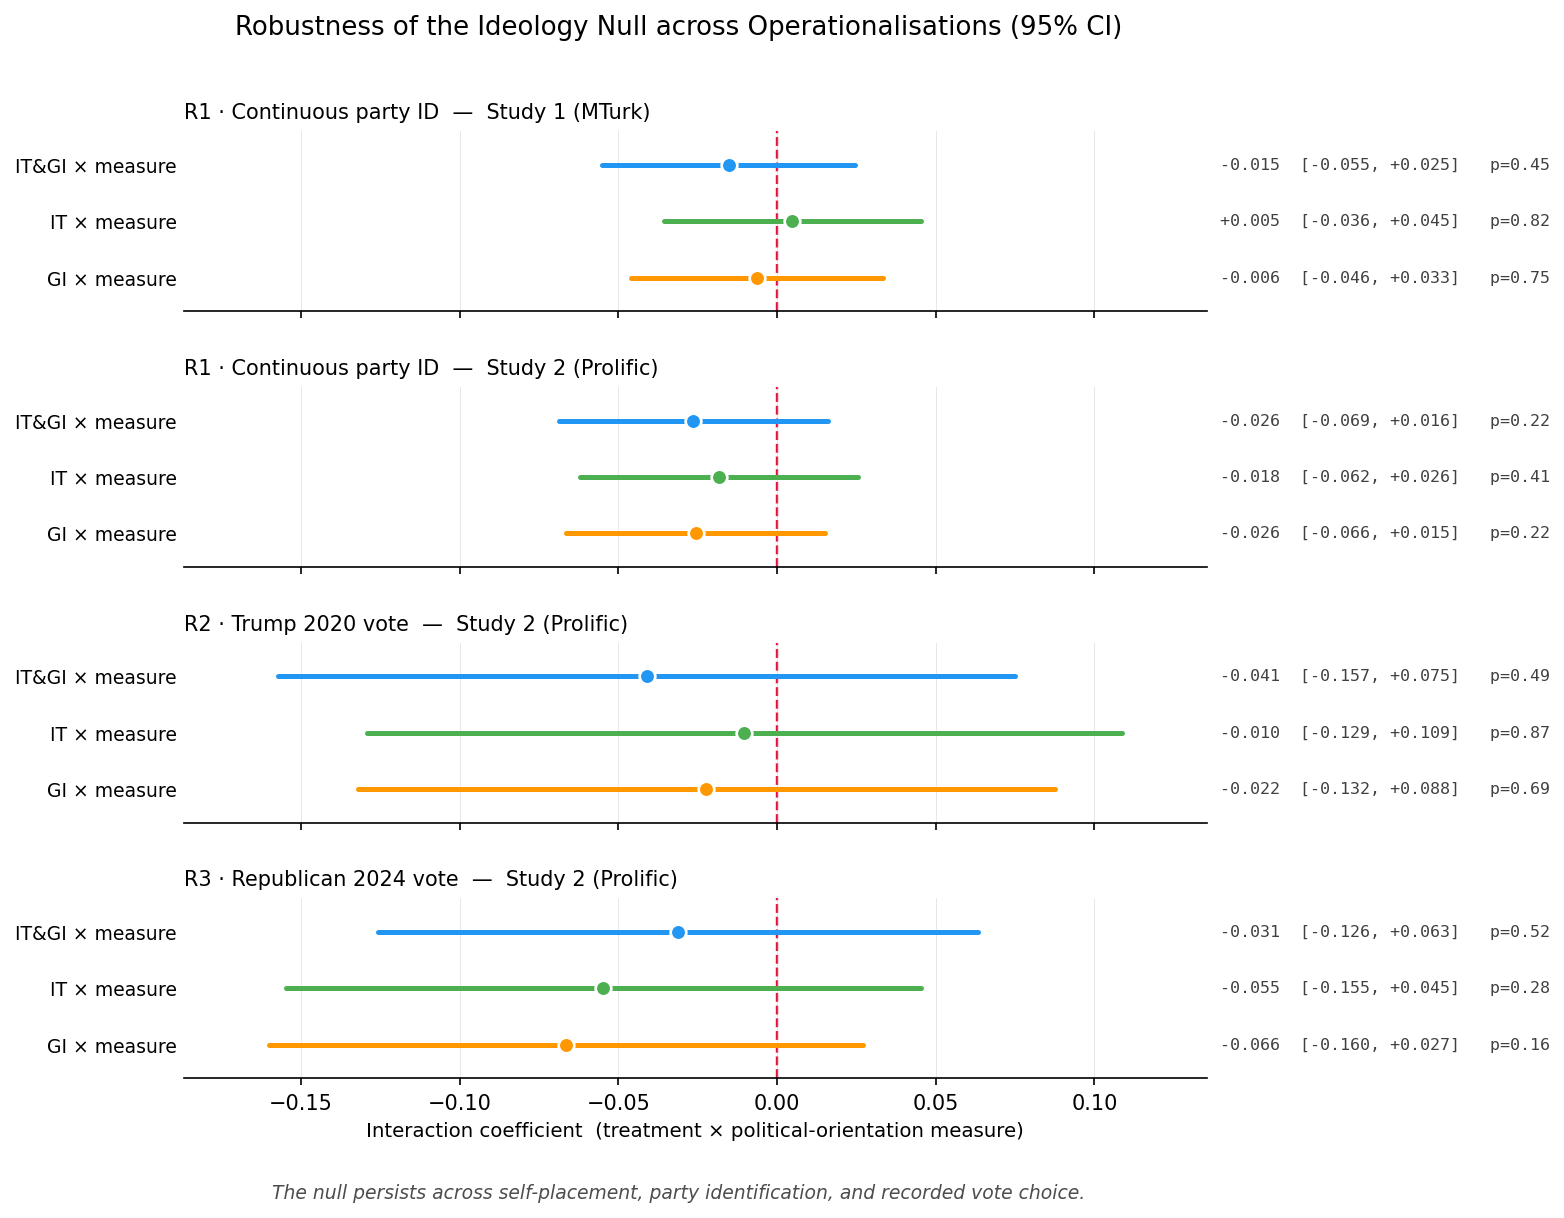

In [10]:
# Cell 9: Figure — forest plot of focal robustness interaction terms
R_PANELS = [
    ('R1 · Continuous party ID',    'Study 1 (MTurk)',    res_r1_mt, 'party_id_z'),
    ('R1 · Continuous party ID',    'Study 2 (Prolific)', res_r1_pr, 'party_id_z'),
    ('R2 · Trump 2020 vote',        'Study 2 (Prolific)', res_r2_pr, 'voted_trump_2020'),
    ('R3 · Republican 2024 vote',   'Study 2 (Prolific)', res_r3_pr, 'voted_rep_2024'),
]
CONTRASTS = [('[T.1]', 'IT&GI'), ('[T.2]', 'IT'), ('[T.3]', 'GI')]

lo_all, hi_all = 0.0, 0.0
for _, _, res, mod in R_PANELS:
    ci = res.conf_int()
    for tag, _ in CONTRASTS:
        t = f'C(treatment, Treatment(reference=4)){tag}:{mod}'
        lo_all = min(lo_all, ci.loc[t, 0]); hi_all = max(hi_all, ci.loc[t, 1])
pad = (hi_all - lo_all) * 0.10

fig, axes = plt.subplots(len(R_PANELS), 1, figsize=(8.8, 8.2), sharex=True,
                         gridspec_kw={'hspace': 0.42})

for ax, (rlabel, study, res, mod) in zip(axes, R_PANELS):
    ci = res.conf_int()
    ylabels = []
    for i, (tag, tname) in enumerate(reversed(CONTRASTS)):
        t = f'C(treatment, Treatment(reference=4)){tag}:{mod}'
        b, lo, hi, p = res.params[t], ci.loc[t, 0], ci.loc[t, 1], res.pvalues[t]
        colour = TREAT_COLORS[tname]
        ax.plot([lo, hi], [i, i], color=colour, lw=2.4, solid_capstyle='round', zorder=2)
        ax.plot(b, i, 'o', color=colour, ms=7.5, mec='white', mew=1.3, zorder=3)
        ax.text(hi_all + pad * 1.15, i, f'{b:+.3f}  [{lo:+.3f}, {hi:+.3f}]   p={p:.2f}',
                va='center', fontsize=8, family='monospace', color='0.25')
        ylabels.append(f'{tname} \u00d7 measure')
    ax.axvline(0, color='crimson', ls='--', lw=1.15, zorder=1)
    ax.set_yticks(range(len(CONTRASTS)))
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_ylim(-0.6, len(CONTRASTS) - 0.4)
    ax.set_xlim(lo_all - pad, hi_all + pad)
    ax.set_title(f'{rlabel}  \u2014  {study}', fontsize=10, loc='left', pad=6)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', lw=0.4, alpha=0.35)

axes[-1].set_xlabel('Interaction coefficient  (treatment \u00d7 political-orientation measure)', fontsize=9.5)
fig.suptitle('Robustness of the Ideology Null across Operationalisations (95% CI)',
             fontsize=12.5, y=0.975)
fig.text(0.5, 0.012,
         'The null persists across self-placement, party identification, and recorded vote choice.',
         ha='center', fontsize=9, style='italic', color='0.3')
plt.savefig('outputs/figures/fig_robustness_forest.png', dpi=200, bbox_inches='tight')
plt.show()